SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2951
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


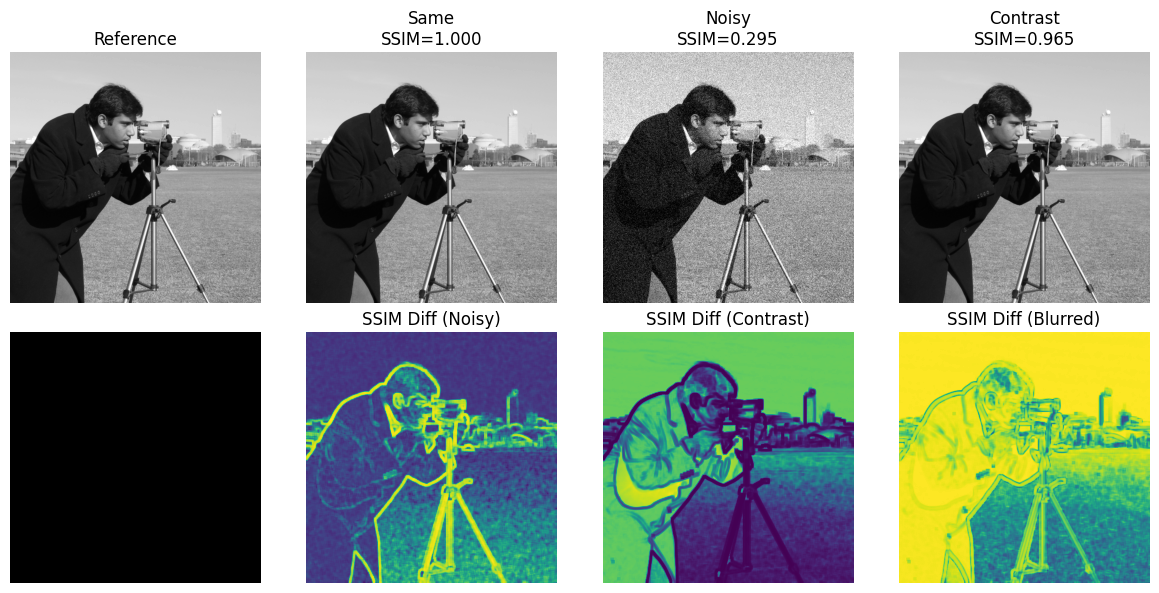

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# Muat dan buat variasi citra
image_ref = img_as_float(data.camera())
image_same = image_ref.copy()
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
image_blurred = gaussian(image_ref, sigma=1.5)

# Hitung SSIM
data_range = image_ref.max() - image_ref.min()
ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.ravel()
axes[0].imshow(image_ref, cmap='gray'); axes[0].set_title('Reference'); axes[0].axis('off')
axes[1].imshow(image_same, cmap='gray'); axes[1].set_title(f'Same\nSSIM={ssim_same:.3f}'); axes[1].axis('off')
axes[2].imshow(image_noisy, cmap='gray'); axes[2].set_title(f'Noisy\nSSIM={ssim_noisy:.3f}'); axes[2].axis('off')
axes[3].imshow(image_contrast, cmap='gray'); axes[3].set_title(f'Contrast\nSSIM={ssim_contrast:.3f}'); axes[3].axis('off')
axes[4].imshow(np.zeros_like(image_ref), cmap='gray'); axes[4].axis('off')
axes[5].imshow(diff_noisy, cmap='viridis'); axes[5].set_title('SSIM Diff (Noisy)'); axes[5].axis('off')
axes[6].imshow(diff_contrast, cmap='viridis'); axes[6].set_title('SSIM Diff (Contrast)'); axes[6].axis('off')
axes[7].imshow(diff_blurred, cmap='viridis'); axes[7].set_title('SSIM Diff (Blurred)'); axes[7].axis('off')
plt.tight_layout(); plt.show()

Tugas Lanjutan:
Amati nilai SSIM untuk setiap kasus. Apakah SSIM untuk citra yang sama bernilai 1? Bagaimana nilai SSIM untuk citra yang diberi noise, diubah kontrasnya, atau di-blur? Apakah nilai SSIM ini sesuai dengan persepsi visual Anda tentang kemiripan? Amati peta perbedaan SSIM, area mana yang menunjukkan ketidakmiripan struktural terbesar?